KAPREKAR EXPLORER: FINITE ALPHABET ATTRACTOR STATES

FINITIST INSIGHT: FINITE ALPHABET → FINITE STATES → ATTRACTORS

The Kaprekar process demonstrates structural completion:
  • Finite digit set {0,1,...,9} → finite state space
  • Deterministic iteration → must converge or cycle
  • Constants (6174, 495) are attractor fixed points
  • No infinite behavior possible (pigeonhole principle)

EXPLORING 3-DIGIT NUMBERS

Convergence Results (sample size: 500):
  Cycle (len=2): 500 (100.0%)

Unique cycles discovered: 1
  Cycle 1: (495, 495)

EXPLORING 4-DIGIT NUMBERS

Convergence Results (sample size: 500):
  Cycle (len=2): 500 (100.0%)

Unique cycles discovered: 1
  Cycle 1: (6174, 6174)

EXPLORING 5-DIGIT NUMBERS

Convergence Results (sample size: 500):
  Cycle (len=5): 491 (98.2%)
  Cycle (len=3): 9 (1.8%)

Unique cycles discovered: 9
  Cycle 1: (62964, 71973, 74943, 74943, 83952)
  Cycle 2: (62964, 71973, 74943, 83952, 83952)
  Cycle 3: (61974, 61974, 63954, 75933, 82962)
  Cycle 4: (6296

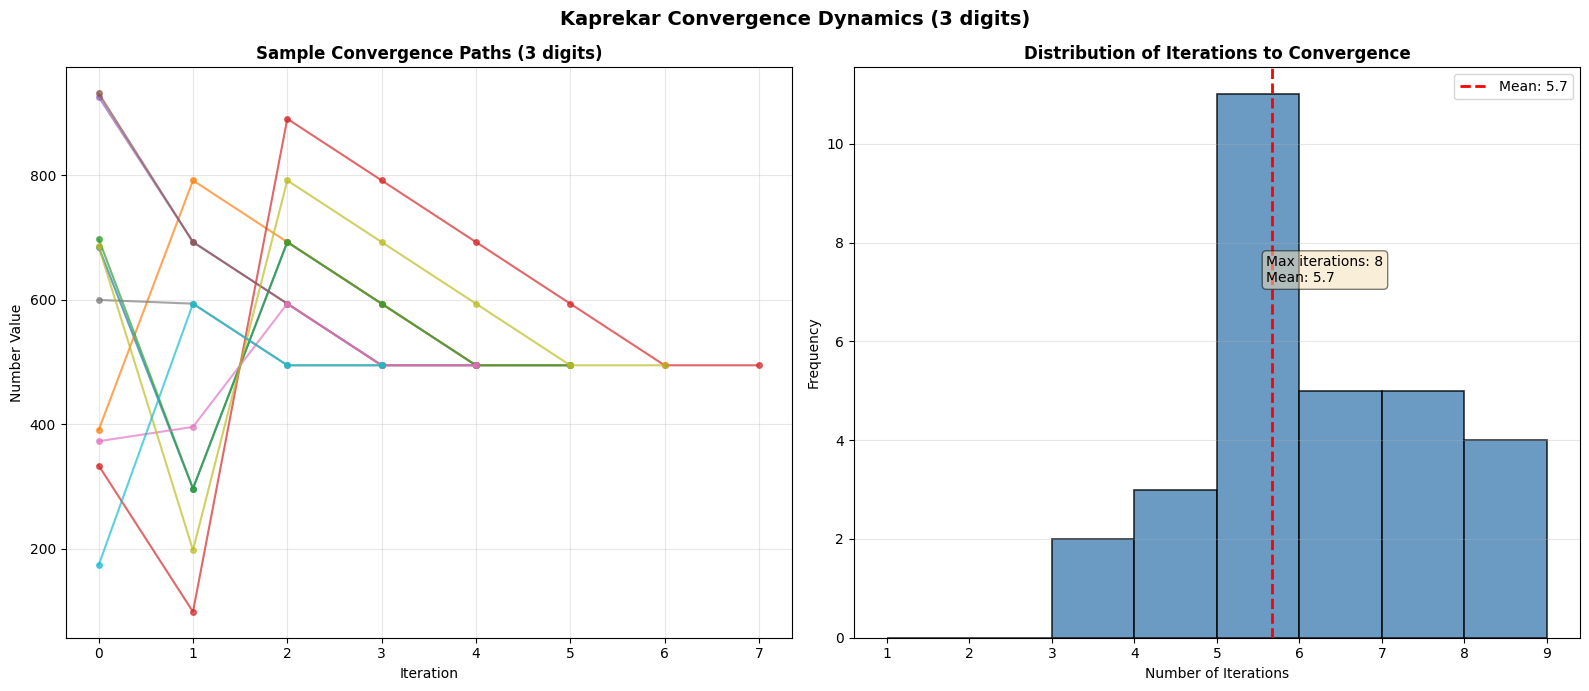


VISUALIZING CONVERGENCE FOR 4 DIGITS

✓ Saved: kaprekar_convergence_4digits.png


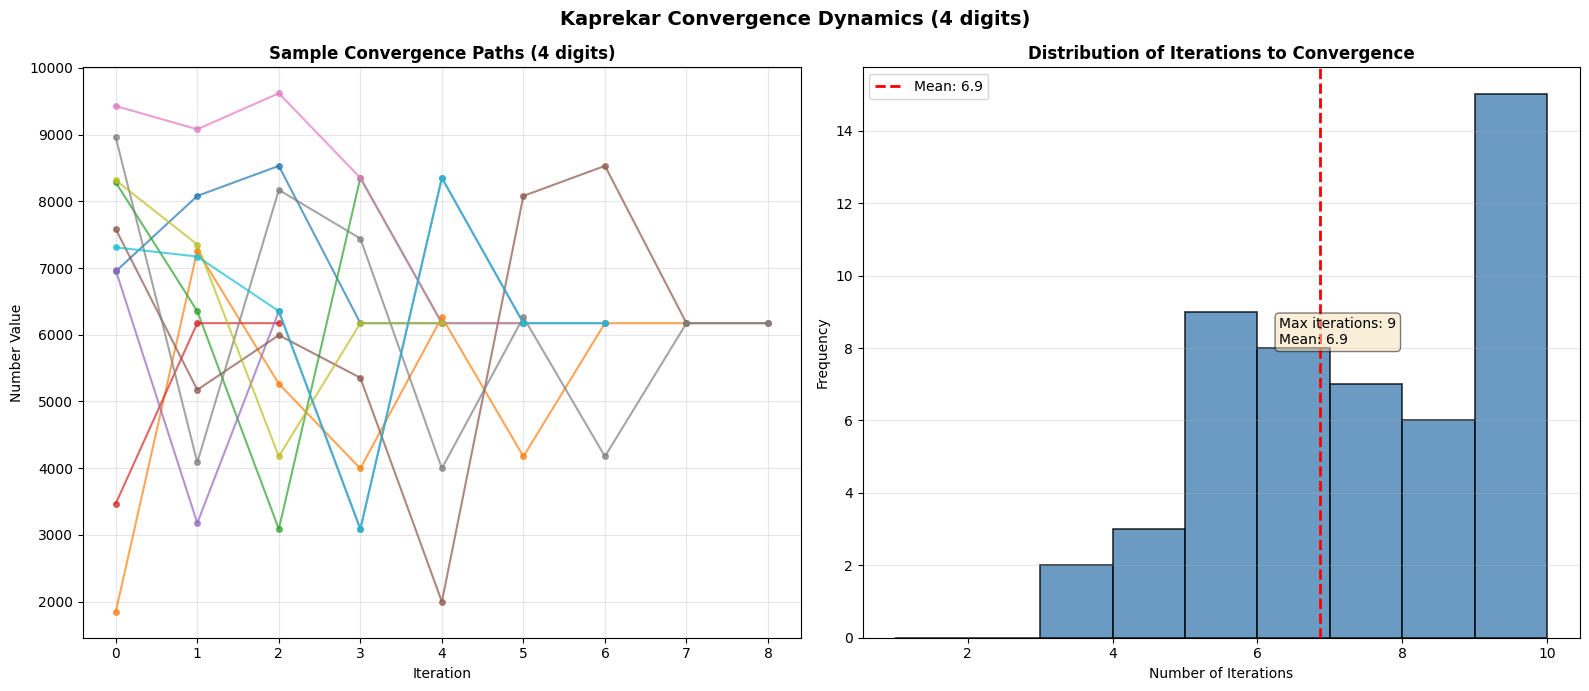


DEMONSTRATION: CONVERGENCE TO CONSTANTS

3-digit example (constant = 495):
  532 - 235 = 297
  972 - 279 = 693
  963 - 369 = 594
  954 - 459 = 495

4-digit example (constant = 6174):
  5432 - 2345 = 3087
  8730 - 378 = 8352
  8532 - 2358 = 6174

CONCLUSION
The digits 0-9 form a FINITE ALPHABET.
Iterative operations on finite alphabets MUST converge.
Kaprekar constants are STRUCTURAL COMPLETION POINTS.
This is not coincidence; it is computational necessity.


In [1]:
"""
kaprekar_explorer.py
=====================
Exploring Kaprekar Constants and Cycles as Evidence of Finite Alphabet Structure.

Demonstrates:
1. 3-digit constant: 495
2. 4-digit constant: 6174
3. 5+ digit behavior: cycles (no single constant)
4. Finite state convergence (pigeonhole principle in action)

Author: Néstor E. Ramos
For: "The Pixelated Universe" - Finite Alphabet Dynamics
"""

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

print("=" * 70)
print("KAPREKAR EXPLORER: FINITE ALPHABET ATTRACTOR STATES")
print("=" * 70)

# =============================================================================
# KAPREKAR OPERATIONS
# =============================================================================

def kaprekar_step(n, num_digits=4):
    """
    Single Kaprekar iteration: descending - ascending
    """
    # Pad with zeros to ensure num_digits length
    digits = f"{n:0{num_digits}d}"

    # Arrange digits
    desc = int(''.join(sorted(digits, reverse=True)))
    asc = int(''.join(sorted(digits)))

    return desc - asc, desc, asc

def find_kaprekar_attractor(start_num, num_digits=4, max_iter=1000):
    """
    Find the attractor (constant or cycle) for a given starting number.
    Returns: (attractor_type, attractor_value, iterations, path)
    """
    seen = {}
    path = [start_num]
    current = start_num

    for i in range(max_iter):
        if current in seen:
            # Found a cycle or constant
            cycle_start = seen[current]
            cycle = path[cycle_start:]

            if len(cycle) == 1:
                return "constant", cycle[0], i, path
            else:
                return "cycle", cycle, i, path

        seen[current] = i
        current, _, _ = kaprekar_step(current, num_digits)
        path.append(current)

    return "unknown", None, max_iter, path

# =============================================================================
# EXPLORATION FOR DIFFERENT DIGIT LENGTHS
# =============================================================================

def explore_digit_length(num_digits, sample_size=1000):
    """
    Explore Kaprekar behavior for a specific digit length.
    """
    print(f"\n{'='*70}")
    print(f"EXPLORING {num_digits}-DIGIT NUMBERS")
    print(f"{'='*70}")

    # Generate sample numbers (avoiding repdigits like 1111)
    results = defaultdict(int)
    constants_found = set()
    cycles_found = []

    for _ in range(sample_size):
        # Random number with num_digits
        while True:
            n = np.random.randint(10**(num_digits-1), 10**num_digits)
            digits = str(n).zfill(num_digits)
            if len(set(digits)) > 1:  # Not a repdigit
                break

        attr_type, attr_val, iters, path = find_kaprekar_attractor(n, num_digits)

        if attr_type == "constant":
            results[f"Constant {attr_val}"] += 1
            constants_found.add(attr_val)
        elif attr_type == "cycle":
            cycle_key = tuple(sorted(attr_val))
            results[f"Cycle (len={len(attr_val)})"] += 1
            if cycle_key not in cycles_found:
                cycles_found.append(cycle_key)

    # Print results
    print(f"\nConvergence Results (sample size: {sample_size}):")
    for result, count in sorted(results.items(), key=lambda x: -x[1]):
        print(f"  {result}: {count} ({count/sample_size*100:.1f}%)")

    if constants_found:
        print(f"\nConstants discovered: {sorted(constants_found)}")

    if cycles_found:
        print(f"\nUnique cycles discovered: {len(cycles_found)}")
        for i, cycle in enumerate(cycles_found[:5]):  # Show first 5
            print(f"  Cycle {i+1}: {cycle}")

    return constants_found, cycles_found

# =============================================================================
# VISUALIZATION: CONVERGENCE PATHS
# =============================================================================

def visualize_convergence(num_digits=4, num_samples=50):
    """
    Visualize convergence paths to the attractor.
    """
    print(f"\n{'='*70}")
    print(f"VISUALIZING CONVERGENCE FOR {num_digits} DIGITS")
    print(f"{'='*70}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Track iterations to convergence
    all_iterations = []
    final_values = []

    for _ in range(num_samples):
        while True:
            n = np.random.randint(10**(num_digits-1), 10**num_digits)
            digits = str(n).zfill(num_digits)
            if len(set(digits)) > 1:
                break

        _, _, iters, path = find_kaprekar_attractor(n, num_digits)
        all_iterations.append(len(path))
        final_values.append(path[-1])

        # Plot individual paths (first 10 samples for clarity)
        if len(all_iterations) <= 10:
            ax1.plot(range(len(path)), path, 'o-', alpha=0.7, linewidth=1.5, markersize=4)

    # Left panel: Sample convergence paths
    ax1.set_title(f"Sample Convergence Paths ({num_digits} digits)", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Number Value")
    ax1.grid(True, alpha=0.3)

    # Right panel: Distribution of iterations
    ax2.hist(all_iterations, bins=range(1, max(all_iterations)+2),
             edgecolor='black', linewidth=1.2, color='steelblue', alpha=0.8)
    ax2.set_title(f"Distribution of Iterations to Convergence", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Number of Iterations")
    ax2.set_ylabel("Frequency")
    ax2.grid(True, alpha=0.3, axis='y')

    # Add statistics
    mean_iters = np.mean(all_iterations)
    max_iters = max(all_iterations)
    ax2.axvline(mean_iters, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_iters:.1f}')
    ax2.text(max_iters * 0.7, max(all_iterations) * 0.9,
            f"Max iterations: {max_iters}\nMean: {mean_iters:.1f}",
            fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax2.legend()

    plt.suptitle(f"Kaprekar Convergence Dynamics ({num_digits} digits)",
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    fig.savefig(f"kaprekar_convergence_{num_digits}digits.png", dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: kaprekar_convergence_{num_digits}digits.png")
    plt.show()

# =============================================================================
# MAIN EXPLORATION
# =============================================================================

def main():
    print("\n" + "="*70)
    print("FINITIST INSIGHT: FINITE ALPHABET → FINITE STATES → ATTRACTORS")
    print("="*70)
    print("\nThe Kaprekar process demonstrates structural completion:")
    print("  • Finite digit set {0,1,...,9} → finite state space")
    print("  • Deterministic iteration → must converge or cycle")
    print("  • Constants (6174, 495) are attractor fixed points")
    print("  • No infinite behavior possible (pigeonhole principle)")
    print("="*70)

    # Explore different digit lengths
    for num_digits in [3, 4, 5, 6]:
        explore_digit_length(num_digits, sample_size=500)

    # Visualize convergence for 3 and 4 digits
    visualize_convergence(num_digits=3, num_samples=30)
    visualize_convergence(num_digits=4, num_samples=50)

    # Demonstrate specific examples
    print("\n" + "="*70)
    print("DEMONSTRATION: CONVERGENCE TO CONSTANTS")
    print("="*70)

    # 3-digit example
    print("\n3-digit example (constant = 495):")
    n = 352
    path = [n]
    for _ in range(10):
        next_n, desc, asc = kaprekar_step(n, 3)
        print(f"  {desc} - {asc} = {next_n}")
        if next_n == 495:
            break
        n = next_n
        path.append(n)

    # 4-digit example
    print("\n4-digit example (constant = 6174):")
    n = 3524
    for _ in range(10):
        next_n, desc, asc = kaprekar_step(n, 4)
        print(f"  {desc} - {asc} = {next_n}")
        if next_n == 6174:
            break
        n = next_n

    print("\n" + "="*70)
    print("CONCLUSION")
    print("="*70)
    print("The digits 0-9 form a FINITE ALPHABET.")
    print("Iterative operations on finite alphabets MUST converge.")
    print("Kaprekar constants are STRUCTURAL COMPLETION POINTS.")
    print("This is not coincidence; it is computational necessity.")
    print("="*70)

if __name__ == "__main__":
    main()